# Playground to manually test a few architectures/hyperparameters
## Train LSTM pipeline and plot rolling forecasts for test profiles

In [1]:
from pathlib import Path

from rabl.machine_learning.lstm_pipeline import (
    LSTMPipeline,
    LSTMPipelineConfig,
    test_and_save_forecasts,
    clear_cuda_cache,
)

In [3]:
batch_size = 128
epochs = 30
seed = 123
max_plots = 5

n_lstm = 1
lstm_hidden = 384              # shared across stacked layers
lstm_dropout = 0.3            # ignored if n_lstm == 1 in nn.LSTM

n_fc = 1
fc_hidden = (256,)

learning_rate = 1e-4
preload_training_data = True


h5_path = Path("../outputs/datasets/scaled_split/lstm_merged_batches_0001-0002_k12_minmax_train0.70_val0.15_test0.15.h5")
out_dir = Path(f"../outputs/ml_results/training_playground/")
out_dir.mkdir(parents=True, exist_ok=True)

print("h5_path exists:", h5_path.exists())
print("out_dir:", out_dir)

h5_path exists: True
out_dir: ..\outputs\ml_results\training_playground


In [5]:
config = LSTMPipelineConfig(
    h5_path=h5_path,
    batch_size=batch_size,
    seed=seed,
    n_lstm=n_lstm,
    lstm_hidden=lstm_hidden,
    lstm_dropout=lstm_dropout,
    n_fc=n_fc,
    fc_hidden=tuple(fc_hidden),
    learning_rate=learning_rate,
    use_tqdm=False,
)

pipeline = LSTMPipeline(config)

datasets = pipeline.build()
pipeline.inspect()

Dataset summary:
  H5 path:         ..\outputs\datasets\scaled_split\lstm_merged_batches_0001-0002_k12_minmax_train0.70_val0.15_test0.15.h5
  Batch size:      128
  Seed:            123

  Train profiles:  1400
  Val profiles:    300
  Test profiles:   300

  Sample X shape:  (2001, 13, 14)   (per-sample)
  Sample Y shape:  (2001, 13)   (per-sample)

  Train samples:   2,801,400  (~21,886 batches)
  Val samples:     600,300  (~4,690 batches)
  Test samples:    600,300  (profiles used for forecasting)

  loader cardinality (derived from precomputed counts):
    train:          21886
    val_samples:    4690
    val_profile_ds: 300
    test_profile_ds:300

Train batch X shape: torch.Size([128, 13, 14])
Train batch Y shape: torch.Size([128, 13])

Val profile: results_drum_profile_00006
  X profile shape: torch.Size([2001, 13, 14])
  Y profile shape: torch.Size([2001, 13])

Test profile: results_drum_profile_00004
  X profile shape: torch.Size([2001, 13, 14])
  Y profile shape: torch.Size(

Using GPU: NVIDIA GeForce RTX 4060 Ti

Deterministic seed set to: 123
LSTMRegressor architecture:
  Input features: 14
  LSTM layers (1): hidden_size=384, dropout=0.3
  FC layers (1): [256]
  Output targets: 13



C:\Users\Logan\anaconda3\envs\pymola\Lib\site-packages\torch\nn\modules\rnn.py:83: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "
Preloading train batches: 21886batch [00:24, 875.62batch/s]


Preloaded 21886 training batches to cuda:0 in 25.00s.


Train 1/30: 100%|██████████████████████████████████████████| 21886/21886 [01:07<00:00, 325.99batch/s, loss=4.39291e-06]
Val 1/30: 4690batch [00:08, 529.23batch/s]


Epoch 1/30 - loss: 3.71102e-04 - val_loss: 1.04652e-05 - lr: 1.000e-04 - data_wait: 0.30s - h2d: 0.00s - compute: 56.83s - val_time: 8.86s - preloaded: True - preload_time: 25.00s - max_cuda_mem: 2202.47 MB


...

Epoch 22/30 - loss: 1.92471e-07 - val_loss: 5.83371e-07 - lr: 1.000e-04 - data_wait: 0.29s - h2d: 0.00s - compute: 54.39s - val_time: 8.83s - preloaded: True - preload_time: 25.00s - max_cuda_mem: 2202.47 MB
Early stopping check: 8/10 epochs without validation improvement.


Train 23/30: 100%|█████████████████████████████████████████| 21886/21886 [01:04<00:00, 337.88batch/s, loss=1.79127e-07]
Val 23/30: 4690batch [00:08, 531.75batch/s]


Epoch 23/30 - loss: 1.82836e-07 - val_loss: 1.54726e-06 - lr: 1.000e-04 - data_wait: 0.29s - h2d: 0.00s - compute: 54.67s - val_time: 8.82s - preloaded: True - preload_time: 25.00s - max_cuda_mem: 2202.47 MB
Early stopping check: 9/10 epochs without validation improvement.


Train 24/30: 100%|█████████████████████████████████████████| 21886/21886 [01:04<00:00, 339.11batch/s, loss=1.79495e-07]
Val 24/30: 4690batch [00:08, 537.17batch/s]


Epoch 24/30 - loss: 1.77934e-07 - val_loss: 5.25352e-07 - lr: 1.000e-04 - data_wait: 0.29s - h2d: 0.00s - compute: 54.49s - val_time: 8.73s - preloaded: True - preload_time: 25.00s - max_cuda_mem: 2202.47 MB
Early stopping check: 10/10 epochs without validation improvement.
Early stopping triggered at epoch 24; best validation loss was 1.57193e-07 at epoch 14.
Saved PyTorch profiler summary to ..\outputs\ml_results\training_playground\torch_profiler_summary.txt
Saved PyTorch profiler traces to ..\outputs\ml_results\training_playground\torch_profiler_traces
Restored best model weights from epoch 14.
Saved training curves to ..\outputs\ml_results\training_playground\lstm_train_val_curve.png
Saved learning-rate curve to ..\outputs\ml_results\training_playground\lstm_lr_curve.png

Timing summary (cumulative):
  preload_time: 25.00s
  train_data_wait_time: 7.21s
  train_h2d_time: 0.07s
  train_compute_time: 1331.40s
  train_epoch_time_total: 1338.68s
  val_time_total: 211.84s
  estimated_to

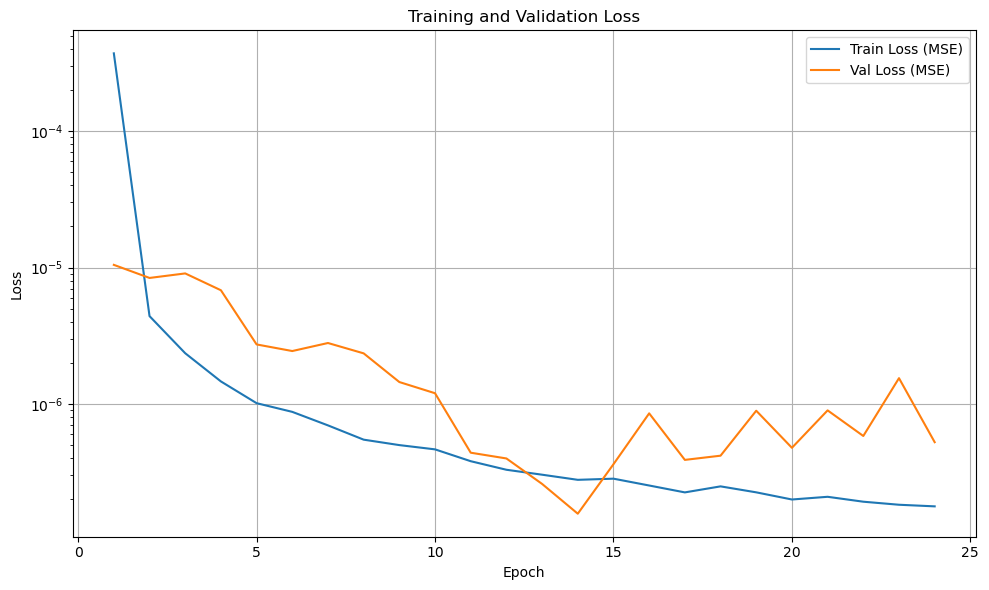

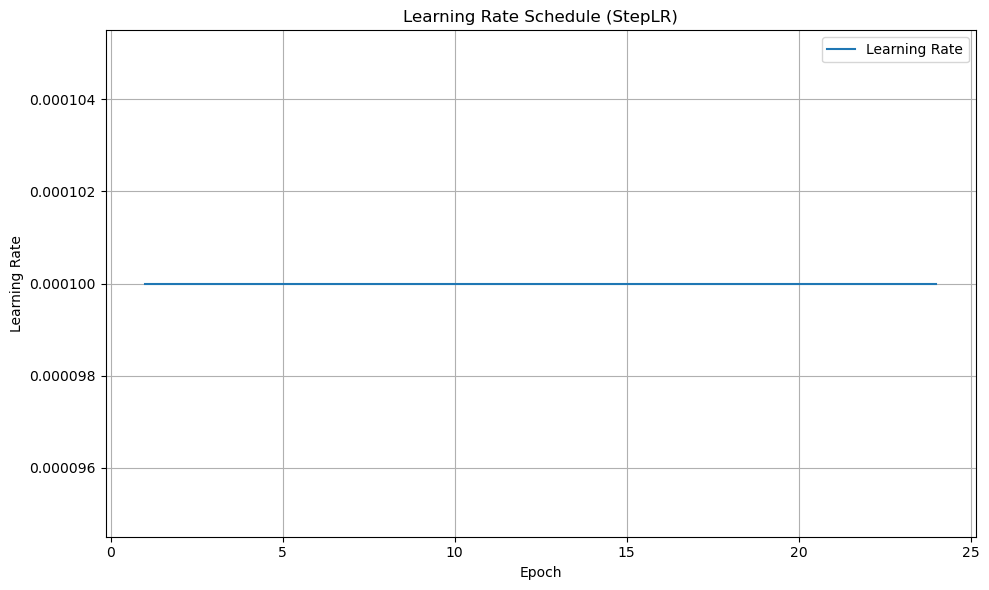

In [7]:
# model, history, used_device = pipeline.train(
#     epochs=epochs,
#     out_dir=out_dir,
#     preload_train_to_device=preload_training_data,
#     early_stopping_min_delta=1e-6,
#     early_stopping_patience=10,
#     restore_best_weights=True,
#     step_lr_step_size=30,
#     step_lr_gamma=0.5
# )
# print(f"Finished training using device: {used_device}")

model, history, used_device = pipeline.train(
    epochs=epochs,
    out_dir=out_dir,
    preload_train_to_device=preload_training_data,
    early_stopping_min_delta=0.0,
    early_stopping_patience=10,
    restore_best_weights=True,
    step_lr_step_size=30,
    step_lr_gamma=0.5,

    # --- profiler options ---
    enable_torch_profiler=True,
    profiler_wait_steps=5,
    profiler_warmup_steps=3,
    profiler_active_steps=10,
    profiler_repeat=2,
    profiler_row_limit=50,
)


In [9]:
test_and_save_forecasts(
    model,
    datasets["test_profile_ds"],
    out_dir=out_dir,
    state_dim=pipeline.config.state_dim,
    control_channel=pipeline.config.control_channel,
    target_names=pipeline.config.target_names,
    max_plots=max_plots,
    plot_callback=pipeline.plot,
    h5_path=h5_path,
)

if "cuda" in str(used_device).lower():
    print(f"Clearing {used_device}...")
    del model
    clear_cuda_cache()

Forecast profiles: 1profile [00:02,  2.87s/profile, mae_avg=2.575435e+03]

Saved forecast plot to: ..\outputs\ml_results\training_playground\rolling_forecast_results_drum_profile_00004.png


Forecast profiles: 2profile [00:05,  2.77s/profile, mae_avg=4.829087e+03]

Saved forecast plot to: ..\outputs\ml_results\training_playground\rolling_forecast_results_drum_profile_00007.png


Forecast profiles: 3profile [00:08,  2.77s/profile, mae_avg=3.044652e+03]

...

Saved forecast plot to: ..\outputs\ml_results\training_playground\rolling_forecast_results_drum_profile_00009.png


Forecast profiles: 5profile [00:13,  2.73s/profile, mae_avg=2.217725e+03]

Saved forecast plot to: ..\outputs\ml_results\training_playground\rolling_forecast_results_drum_profile_00016.png


Forecast profiles: 300profile [06:04,  1.22s/profile, mae_avg=1.937962e+03]



Testing timing summary: total_fetch: 0.0002s -  total_test: 353.9148s -  avg_fetch_profile: 0.0000s -  avg_inference_profile: 1.1797s -  save_time: 0.1499s

Clearing cuda:0...
